# 07: Figure Generation for pLLPS Analysis

Simplified figures for publication:
- Figure 1: Membrane vs Total pLLPS (violin + box)
- Figure 2: Membrane vs Cytosolic pLLPS (violin + box)
- Figure 3: Membrane proteins by Function and Location (separate violins)
- Figure 4: Membrane functional categories (Ion Channel vs Transporter vs GPCR)

## 1. Import Libraries and Load Data

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import llps_functions as lf
from scipy import stats

# Configure plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Create figures directory
fig_dir = Path('results/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

# Define a consistent color palette
COLOR_PALETTE = {
    'Membrane': '#FF7F50',  # coral
    'Non-Membrane': '#4682B4',  # steelblue
    'Total': '#D3D3D3',  # lightgray
    'Cytosolic': '#3CB371',  # mediumseagreen
    'Ion Channel': '#FFD700',  # gold
    'Transporter': '#FF8C00',  # darkorange
    'GPCR': '#8B008B',  # darkviolet
    'Other': '#A9A9A9',  # darkgray
    'Unknown': '#B0C4DE'  # lightsteelblue
}

print("✅ Libraries loaded")

✅ Libraries loaded


In [19]:
# Load the enriched dataset with functional groups
df = pd.read_csv('results/functional_groups_with_pllps.csv')

print(f"\n📊 Dataset loaded")
print(f"   Shape: {df.shape}")
print(f"   pLLPS range: {df['p(LLPS)'].min():.3f} - {df['p(LLPS)'].max():.3f}")
print(f"   Functional groups: {df['Functional Group'].unique().tolist()}")


📊 Dataset loaded
   Shape: (20366, 15)
   pLLPS range: 0.060 - 1.000
   Functional groups: ['Structural', 'Other', 'Enzyme', 'Receptor Tyrosine Kinase', 'Ion Channel', 'Transporter', 'GPCR']


In [20]:
# Add location categories and membrane classifications
if 'is_membrane' not in df.columns:
    df['is_membrane'] = df.apply(
        lambda row: lf.is_membrane_protein(
            row.get('Function [CC]', ''),
            row.get('Protein names', ''),
            row.get('Subcellular location [CC]', '')
        ),
        axis=1
    )

df['location_category'] = df.apply(
    lambda row: lf.categorize_location_to_compartment(
        row['Subcellular location [CC]'],
        is_membrane=row['is_membrane']
    ),
    axis=1
)

mem_count = df['is_membrane'].sum()
print(f"\n🔍 Proteins: {len(df)} total, {mem_count} membrane ({mem_count/len(df)*100:.1f}%)")


🔍 Proteins: 20366 total, 8067 membrane (39.6%)


## 2. Figure 1: Membrane vs Total pLLPS

/tmp/ipykernel_102945/177703413.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=violin_data, x='Type', y='pLLPS', ax=ax,
/tmp/ipykernel_102945/177703413.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=violin_data, x='Type', y='pLLPS', ax=ax,


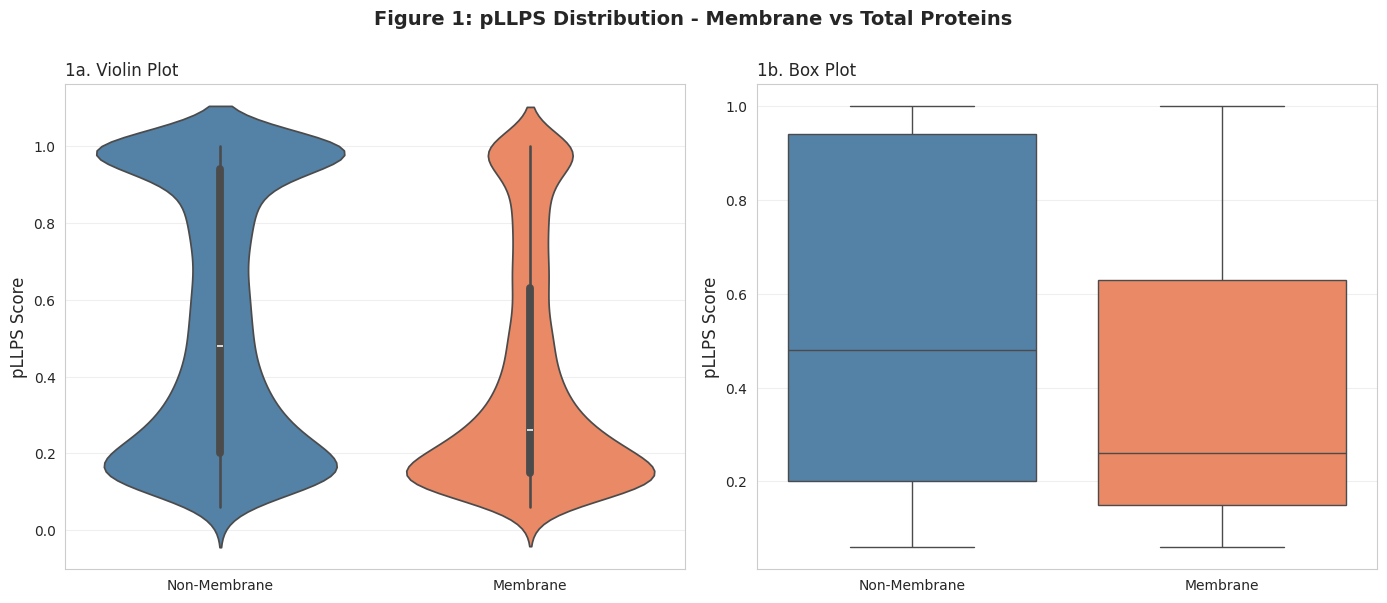


✅ Figure 1 saved
   Membrane: n=8067, mean=0.4003
   Non-Membrane: n=12299, mean=0.5453
   T-test p: 1.56e-203


In [21]:
# Prepare data
violin_data = pd.DataFrame({
    'pLLPS': np.concatenate([
        df[~df['is_membrane']]['p(LLPS)'].dropna(),
        df[df['is_membrane']]['p(LLPS)'].dropna()
    ]),
    'Type': ['Non-Membrane']*len(df[~df['is_membrane']]) + ['Membrane']*len(df[df['is_membrane']])
})

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 1: pLLPS Distribution - Membrane vs Total Proteins', 
             fontsize=14, fontweight='bold', y=1.00)

# 1a. Violin plot
ax = axes[0]
sns.violinplot(data=violin_data, x='Type', y='pLLPS', ax=ax, 
               palette=[COLOR_PALETTE['Non-Membrane'], COLOR_PALETTE['Membrane']])
ax.set_ylabel('pLLPS Score', fontsize=12)
ax.set_xlabel('')
ax.set_title('1a. Violin Plot', fontsize=12, loc='left')
ax.grid(alpha=0.3, axis='y')

# 1b. Box plot
ax = axes[1]
sns.boxplot(data=violin_data, x='Type', y='pLLPS', ax=ax,
            palette=[COLOR_PALETTE['Non-Membrane'], COLOR_PALETTE['Membrane']])
ax.set_ylabel('pLLPS Score', fontsize=12)
ax.set_xlabel('')
ax.set_title('1b. Box Plot', fontsize=12, loc='left')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(fig_dir / 'fig1_membrane_vs_total.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistics
mem = df[df['is_membrane']]['p(LLPS)'].dropna()
non_mem = df[~df['is_membrane']]['p(LLPS)'].dropna()
_, p_val = stats.ttest_ind(mem, non_mem)
print(f"\n✅ Figure 1 saved")
print(f"   Membrane: n={len(mem)}, mean={mem.mean():.4f}")
print(f"   Non-Membrane: n={len(non_mem)}, mean={non_mem.mean():.4f}")
print(f"   T-test p: {p_val:.2e}")

## 3. Figure 2: Membrane vs Cytosolic pLLPS

/tmp/ipykernel_102945/2553448198.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=loc_data, x='Location', y='pLLPS', ax=ax,
/tmp/ipykernel_102945/2553448198.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=loc_data, x='Location', y='pLLPS', ax=ax,


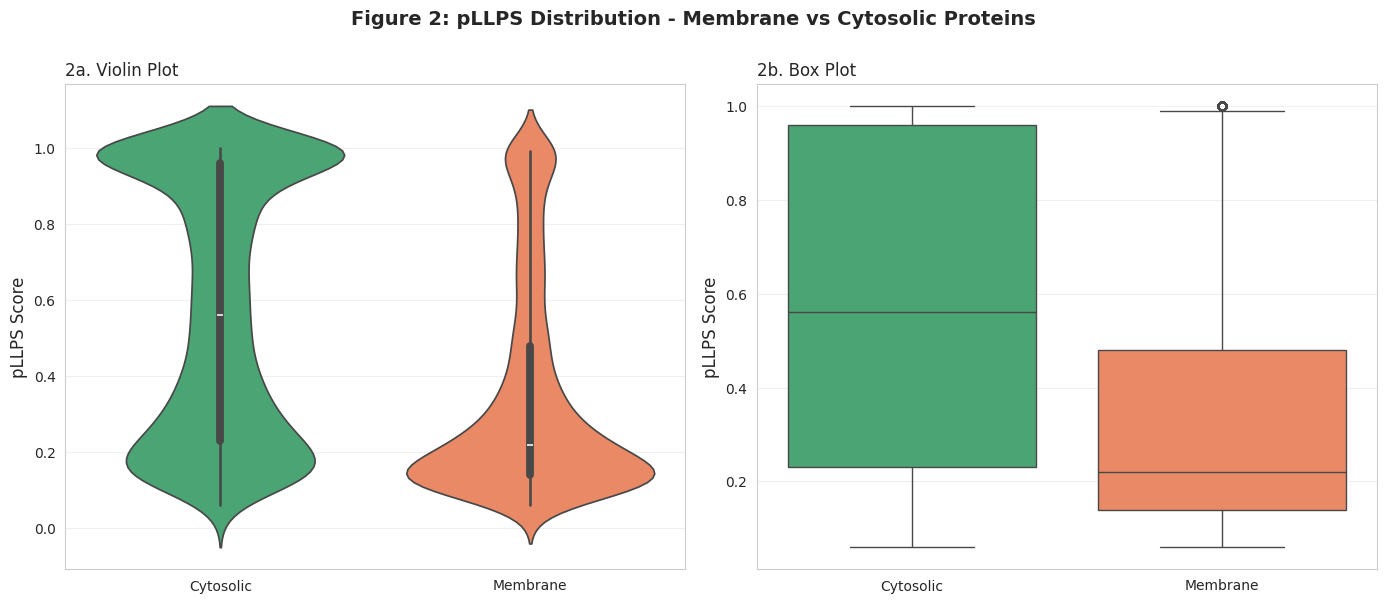


✅ Figure 2 saved
   Cytosolic: n=9059, mean=0.5780
   Membrane: n=5625, mean=0.3489
   T-test p: 0.00e+00


In [22]:
# Categorize location
df['location_type'] = 'Other'
df.loc[df['location_category'].str.contains('Membrane', na=False), 'location_type'] = 'Membrane'
df.loc[df['location_category'] == 'Cytosol', 'location_type'] = 'Cytosolic'

# Prepare data
mem_pllps = df[df['location_type'] == 'Membrane']['p(LLPS)'].dropna()
cyto_pllps = df[df['location_type'] == 'Cytosolic']['p(LLPS)'].dropna()

loc_data = pd.DataFrame({
    'pLLPS': np.concatenate([cyto_pllps, mem_pllps]),
    'Location': ['Cytosolic']*len(cyto_pllps) + ['Membrane']*len(mem_pllps)
})

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 2: pLLPS Distribution - Membrane vs Cytosolic Proteins', 
             fontsize=14, fontweight='bold', y=1.00)

# 2a. Violin plot
ax = axes[0]
sns.violinplot(data=loc_data, x='Location', y='pLLPS', ax=ax,
               palette=[COLOR_PALETTE['Cytosolic'], COLOR_PALETTE['Membrane']])
ax.set_ylabel('pLLPS Score', fontsize=12)
ax.set_xlabel('')
ax.set_title('2a. Violin Plot', fontsize=12, loc='left')
ax.grid(alpha=0.3, axis='y')

# 2b. Box plot
ax = axes[1]
sns.boxplot(data=loc_data, x='Location', y='pLLPS', ax=ax,
            palette=[COLOR_PALETTE['Cytosolic'], COLOR_PALETTE['Membrane']])
ax.set_ylabel('pLLPS Score', fontsize=12)
ax.set_xlabel('')
ax.set_title('2b. Box Plot', fontsize=12, loc='left')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(fig_dir / 'fig2_membrane_vs_cytosolic.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistics
_, p_val = stats.ttest_ind(mem_pllps, cyto_pllps)
print(f"\n✅ Figure 2 saved")
print(f"   Cytosolic: n={len(cyto_pllps)}, mean={cyto_pllps.mean():.4f}")
print(f"   Membrane: n={len(mem_pllps)}, mean={mem_pllps.mean():.4f}")
print(f"   T-test p: {p_val:.2e}")

## 4. Figure 3: Membrane Proteins by Function and Location

/tmp/ipykernel_102945/3406552400.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=mem_df, x='Functional Group', y='p(LLPS)', ax=ax,


AttributeError: 'Index' object has no attribute 'head'

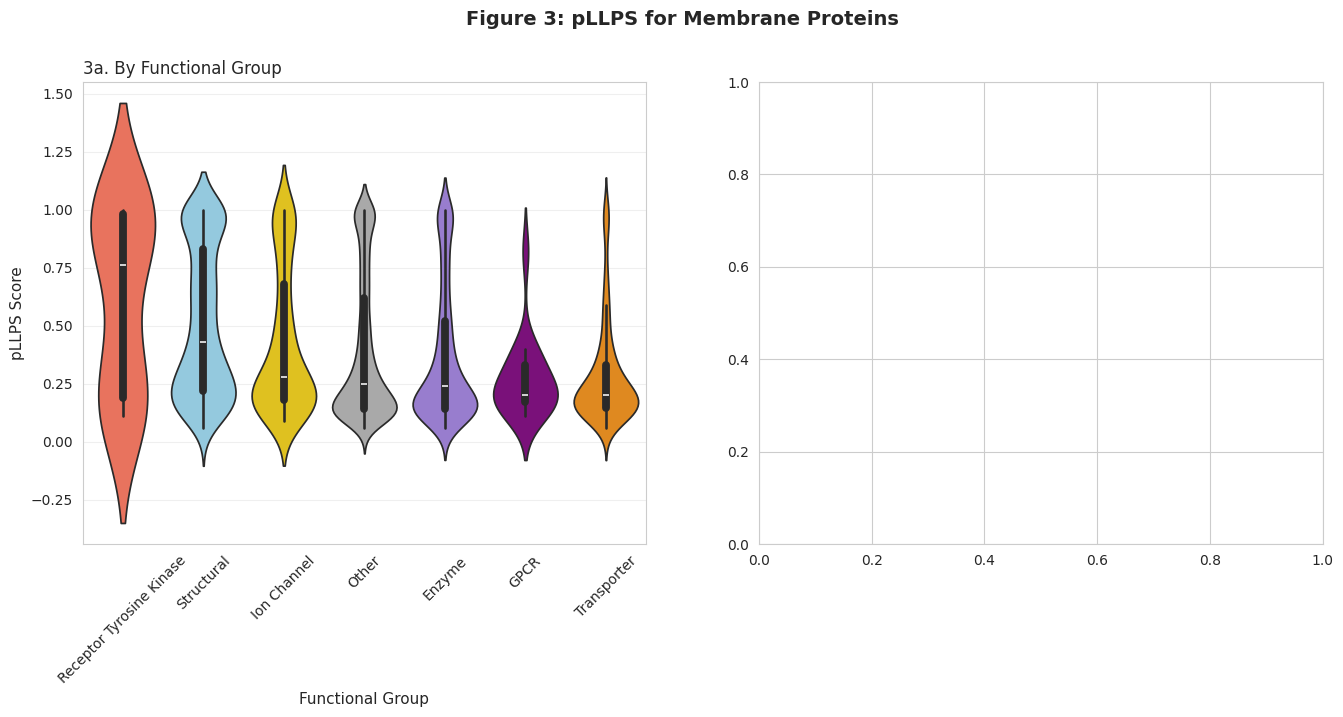

In [23]:
# Get membrane proteins
mem_df = df[df['is_membrane']].copy()

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 3: pLLPS for Membrane Proteins', 
             fontsize=14, fontweight='bold', y=1.00)

# 3a. Violin by Functional Group
ax = axes[0]
order_func = mem_df.groupby('Functional Group')['p(LLPS)'].median().sort_values(ascending=False).index

func_colors = {
    'Ion Channel': COLOR_PALETTE['Ion Channel'],
    'Transporter': COLOR_PALETTE['Transporter'],
    'GPCR': COLOR_PALETTE['GPCR'],
    'Receptor Tyrosine Kinase': '#FF6347',
    'Enzyme': '#9370DB',
    'Structural': '#87CEEB',
    'Other': COLOR_PALETTE['Other']
}
palette_func = [func_colors.get(fg, COLOR_PALETTE['Other']) for fg in order_func]

sns.violinplot(data=mem_df, x='Functional Group', y='p(LLPS)', ax=ax, 
               order=order_func, palette=palette_func)
ax.set_title('3a. By Functional Group', fontsize=12, loc='left')
ax.set_xlabel('Functional Group', fontsize=11)
ax.set_ylabel('pLLPS Score', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3, axis='y')

# 3b. Violin by Location
ax = axes[1]
order_loc = mem_df.groupby('location_category')['p(LLPS)'].median().sort_values(ascending=False).index.head(6)
mem_df_loc = mem_df[mem_df['location_category'].isin(order_loc)]

sns.violinplot(data=mem_df_loc, x='location_category', y='p(LLPS)', ax=ax, 
               order=order_loc, palette='husl')
ax.set_title('3b. By Location (Top 6)', fontsize=12, loc='left')
ax.set_xlabel('Location Category', fontsize=11)
ax.set_ylabel('pLLPS Score', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(fig_dir / 'fig3_membrane_by_function_location.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Figure 3 saved")

## 5. Figure 4: Membrane Functional Categories

/tmp/ipykernel_102945/1704445017.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=mem_func_df, x='membrane_category', y='p(LLPS)', ax=ax,


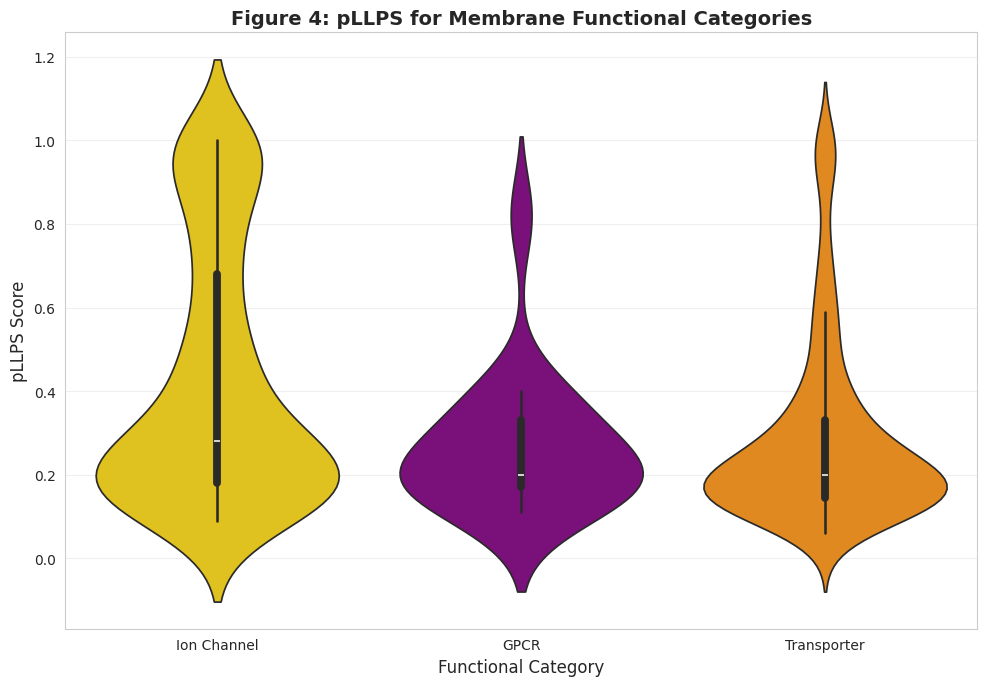


✅ Figure 4 saved
   Ion Channel: n=316, mean=0.4263
   GPCR: n=17, mean=0.2688
   Transporter: n=299, mean=0.2863


In [24]:
# Classify membrane proteins
def classify_membrane_function(row):
    if not row['is_membrane']:
        return 'Other'
    fg = str(row['Functional Group']).lower()
    if 'ion channel' in fg:
        return 'Ion Channel'
    elif 'transporter' in fg:
        return 'Transporter'
    elif 'gpcr' in fg:
        return 'GPCR'
    return 'Other'

df['membrane_category'] = df.apply(classify_membrane_function, axis=1)

# Filter to three categories
mem_func_df = df[df['membrane_category'].isin(['Ion Channel', 'Transporter', 'GPCR'])]

# Create figure
fig, ax = plt.subplots(figsize=(10, 7))

order_cat = mem_func_df.groupby('membrane_category')['p(LLPS)'].median().sort_values(ascending=False).index
cat_palette = [COLOR_PALETTE[cat] for cat in order_cat]

sns.violinplot(data=mem_func_df, x='membrane_category', y='p(LLPS)', ax=ax, 
               order=order_cat, palette=cat_palette, inner='box')
ax.set_title('Figure 4: pLLPS for Membrane Functional Categories', fontsize=14, fontweight='bold')
ax.set_xlabel('Functional Category', fontsize=12)
ax.set_ylabel('pLLPS Score', fontsize=12)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(fig_dir / 'fig4_membrane_categories.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Figure 4 saved")
for cat in order_cat:
    subset = mem_func_df[mem_func_df['membrane_category'] == cat]['p(LLPS)'].dropna()
    print(f"   {cat}: n={len(subset)}, mean={subset.mean():.4f}")

## Summary

In [25]:
# List generated figures
import glob

figures = sorted(glob.glob(str(fig_dir / '*.png')))

print("\n" + "="*70)
print("✅ FIGURE GENERATION COMPLETE")
print("="*70)
print(f"\nGenerated {len(figures)} figures:")
for i, fig in enumerate(figures, 1):
    fig_name = Path(fig).name
    print(f"  {i}. {fig_name}")
print(f"\nOutput directory: {fig_dir.absolute()}")


✅ FIGURE GENERATION COMPLETE

Generated 9 figures:
  1. fig1_membrane_vs_total.png
  2. fig1_membrane_vs_total_pllps.png
  3. fig2_membrane_vs_cytosolic.png
  4. fig2_membrane_vs_cytosolic_pllps.png
  5. fig3_membrane_pllps_by_location_function.png
  6. fig3b_membrane_pllps_boxplot.png
  7. fig4_ion_channels_analysis.png
  8. fig4_membrane_categories.png
  9. fig5_ion_channel_predictors.png

Output directory: /workspaces/mem_prot_llps/results/figures
